# Hate Speech Detection in Kyrgyz — Dataset, Benchmark, and Annotation Schema

**NLP Final Project (Master's program)**  
**Author:** [Your name]  
**Repository:** https://github.com/adiletbaimyrza/kara

## What this notebook does

This notebook runs end-to-end. It builds and benchmarks the **first Kyrgyz hate-speech detection dataset** I am aware of. The structure mirrors the paper (`paper/PAPER.md`):

1. **Dataset** — load 13,902 filtered YouTube comments, the keyword + random candidate pools, and the 1,079 human-labelled gold set.
2. **Annotation** — inspect the label distribution and compute Cohen's κ between the human annotator (me) and Aya-Expanse-8B as a second annotator.
3. **Splits** — stratified 70 / 10 / 20 train/val/test.
4. **Classical ML experiments (4)** — TF-IDF + LogReg/SVM with word and character n-grams. These run inline on CPU in ~10 seconds.
5. **Transformer experiments (2)** — mBERT and XLM-RoBERTa fine-tuning. The actual training was done on Cyfronet Helios GH200 via `slurm/transformers.sbatch`; this notebook loads pre-computed metrics from `results/exp5_mbert/` and `results/exp6_xlmr/`.
6. **LLM experiments (2)** — Aya-Expanse-8B zero-shot and 5-shot. Same pattern: actual runs on Helios via `slurm/llm_eval.sbatch`; this notebook loads pre-computed metrics.
7. **Headline comparison** — all 8 systems side-by-side.
8. **Error analysis** — confusion matrix and categorised error cases for the best model.
9. **Conclusions** — what helped, what didn't, what surprised us.

## Headline finding (preview)

**Classical character-n-gram TF-IDF + Logistic Regression (macro-F1 = 0.646) outperforms every neural system tested** — fine-tuned mBERT (0.557), XLM-RoBERTa (0.431), and Aya-Expanse-8B zero-shot (0.354) and 5-shot (0.393). The post-hoc explanation is the **89.8% Russian-keyboard orthographic prevalence** in Kyrgyz YouTube comments, which mismatches the formal-Cyrillic pretraining distribution of all neural systems. Char-n-grams are orthography-resilient by construction; subword tokenisers are not.

## Required libraries

```
pandas, numpy, scikit-learn, matplotlib, seaborn
```

All installable via `pip install -r requirements.txt`. Transformers and LLM code (for re-running step 5–6 on a GPU) require additional packages — see `slurm/setup_venv.sh`.

## 0. Setup

In [1]:
import json
import pathlib
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RNG_SEED = 42
LABELS = ['non_hate', 'offensive', 'hate']

ROOT = pathlib.Path.cwd().parent
DATA = ROOT / 'data'
RESULTS = ROOT / 'results'
FIGURES = ROOT / 'figures'

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Project root: {ROOT}')
print(f'sklearn ready, seed={RNG_SEED}, classes={LABELS}')

Project root: /Users/adiletuni/repos/nlp/kara
sklearn ready, seed=42, classes=['non_hate', 'offensive', 'hate']


## 1. Dataset

### 1.1 Source: 13 Kyrgyz YouTube videos

I scraped comments from 13 Kyrgyz-language YouTube videos using `yt-dlp`. Video selection prioritized political/news content (where the hate-speech base rate is higher) and channel diversity (4 distinct content domains). After an 11-stage filtering pipeline (`filter_comments.py`), **13,902 unique comments** remain.

In [2]:
comments = pd.read_csv(DATA / 'comments_filtered.csv')
print(f'Filtered comments: {len(comments):,}')
print(f'Distinct videos:   {comments["video_id"].nunique()}')
print(f'Mean words:        {comments["n_words"].mean():.1f}')
with_ky = comments['has_kyrgyz_letters'].sum()
print(f'\nKyrgyz-specific letters (Ң, Ө, Ү):')
print(f'  present: {with_ky:,} ({with_ky/len(comments)*100:.1f}%)')
print(f'  absent (Russian keyboard only): {len(comments)-with_ky:,} ({(1-with_ky/len(comments))*100:.1f}%)')
print('\nThis 89.8% Russian-keyboard prevalence is the dominant orthographic feature of the corpus.')
comments.head(3)

Filtered comments: 13,902
Distinct videos:   13
Mean words:        13.5

Kyrgyz-specific letters (Ң, Ө, Ү):
  present: 1,423 (10.2%)
  absent (Russian keyboard only): 12,479 (89.8%)

This 89.8% Russian-keyboard prevalence is the dominant orthographic feature of the corpus.


,id,video_id,text,likes,date,n_words,has_kyrgyz_letters,cyrillic_ratio,label
0,UgzxrcN0Lp1BZWTl9wJ4AaABAg,8W94yWJHw6A,Камчы бийлике жетиш учун ар кучтуу саясатчылар...,1,1774137600,16,0,1.0,NaN
1,UgxugSO-LO7ppChkAlF4AaABAg,8W94yWJHw6A,Барыле таза эмес экен тооба🇰🇬👍,0,1774137600,5,0,1.0,NaN
2,UgxLNI1u0y0P0OVgmaJ4AaABAg,8W94yWJHw6A,Надира нарматова Каза болоруна аз калыптыр тан...,0,1771718400,8,0,1.0,NaN


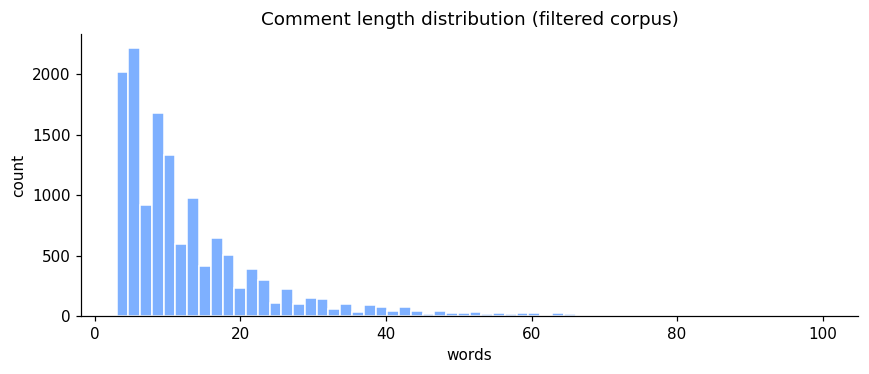

In [3]:
# Comment-length distribution
fig, ax = plt.subplots(figsize=(8, 3.5))
comments['n_words'].plot.hist(bins=60, ax=ax, color='#7eb0ff', edgecolor='white')
ax.set_title('Comment length distribution (filtered corpus)')
ax.set_xlabel('words')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

### 1.2 Candidate sampling (Davidson 2017 methodology)

Annotating all 13,902 comments by hand is infeasible. Following Davidson et al. (2017), I use **biased + random sampling**:

- **Biased pool** (`candidates_hate.csv`): every comment matching ≥1 keyword from a curated 5-category slur/profanity lexicon (Russian profanity, Kyrgyz profanity, anti-LGBT, ethnic, political insults). Latin-letter obfuscation (`pidr`, `кот.к`) is normalised before matching. **702 comments matched (5.0%)**.
- **Random pool** (`candidates_random.csv`): 500 comments drawn uniformly at random from the non-matching set. This pool catches slur-free hate (eliminationist rhetoric, ethnic essentialism) and provides genuine `non_hate` examples.

Total annotation budget: **1,202 candidates**.

Keyword-matched (biased) pool: 702
Random pool:                   500
Total annotation candidates:   1,202


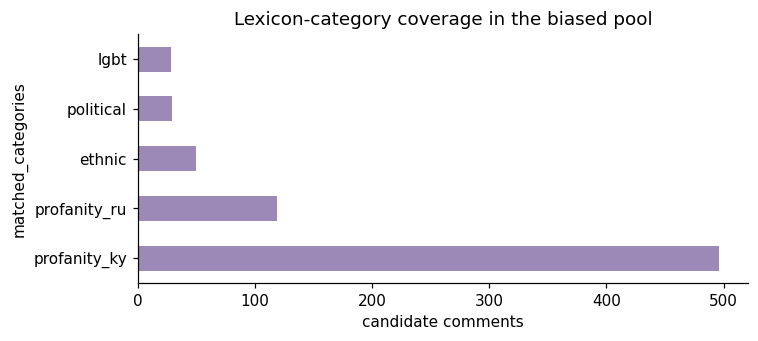

In [4]:
cand_hate = pd.read_csv(DATA / 'candidates_hate.csv').fillna('')
cand_rand = pd.read_csv(DATA / 'candidates_random.csv').fillna('')
print(f'Keyword-matched (biased) pool: {len(cand_hate):,}')
print(f'Random pool:                   {len(cand_rand):,}')
print(f'Total annotation candidates:   {len(cand_hate) + len(cand_rand):,}')

# Per-category match counts within the biased pool
cats = (cand_hate['matched_categories'].str.split('|').explode().str.strip())
cats = cats[cats != ''].value_counts()

fig, ax = plt.subplots(figsize=(7, 3.2))
cats.plot.barh(ax=ax, color='#9c89b8')
ax.set_title('Lexicon-category coverage in the biased pool')
ax.set_xlabel('candidate comments')
plt.tight_layout()
plt.show()

### 1.3 Annotation

Schema: 3 classes (`hate` / `offensive` / `non_hate`) based on Davidson (2017) with two extensions and three carve-outs (fully documented in `DISCOVERIES.md`):

- **Extension 1**: protected-attribute slurs used as generic invective (e.g. anti-LGBT slur at a non-LGBT politician) still count as `hate`.
- **Extension 2**: explicit calls for violence/death against any identifiable target count as `hate`.
- **Carve-out (a)**: dehumanisation without protected-attribute target stays `offensive`.
- **Carve-out (b)**: optative-mood Turkic-Islamic curses (`наалат`, `Аллах жазалайт`, `жер жутсун`) stay `offensive` even when content-genocidal.
- **Carve-out (c)**: violent imperatives against criminal-behaviour categories (pedophiles, corrupt politicians-framed-as-criminals) stay `offensive`.

I annotated all 1,202 candidates myself using a terminal CLI (`src/annotate_cli.py`) over ~8 hours. The annotation log shows a median 8.6 sec/sample. After dropping `skip` (10.2%), **1,079 gold-labelled comments** remain.

Total annotated: 1,202
  non_hate       472  (39.3%)
  offensive      343  (28.5%)
  hate           264  (22.0%)
  skip           123  (10.2%)


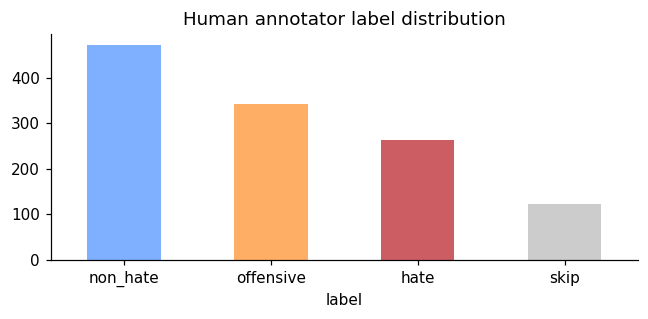

In [5]:
human = pd.read_csv(DATA / 'annotated' / 'annotations_human.csv')
print(f'Total annotated: {len(human):,}')
label_counts = human['label'].value_counts().reindex(['non_hate', 'offensive', 'hate', 'skip']).fillna(0).astype(int)
for lab in label_counts.index:
    n = label_counts[lab]
    print(f'  {lab:<12} {n:>5}  ({n/len(human)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 3))
label_counts.plot.bar(ax=ax, color=['#7eb0ff', '#ffae65', '#cc5e63', '#cccccc'])
ax.set_title('Human annotator label distribution')
ax.set_xticklabels(label_counts.index, rotation=0)
plt.tight_layout()
plt.show()

### 1.4 LLM as second annotator: Inter-annotator agreement

Aya-Expanse-8B (CohereForAI) was deployed on Cyfronet Helios GH200 to independently label the same 1,202 candidates using the same Davidson-extended schema prompt (see `src/annotate_llm.py`). I compute Cohen's κ between the human (me) and the LLM on the 1,079 items where the human label is not `skip`.

**Headline IAA finding**: κ = 0.100 (raw agreement = 0.361), classed as "slight agreement" under Landis & Koch (1977). The LLM **systematically over-predicts `hate`** — see confusion matrix below.

Cohen's κ (3-class):   0.100
Raw agreement:         0.361
Overlap items (n):     1079

Agreement when the human said …
  non_hate     0.148  (n=472)
  offensive    0.452  (n=343)
  hate         0.625  (n=264)


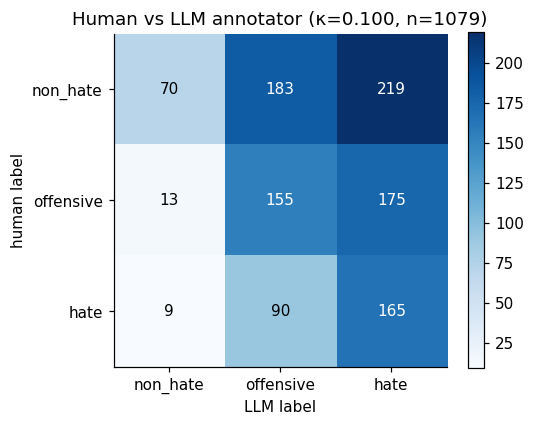


The LLM predicts `hate` 46% of the time the human said `non_hate` and 51% of the time the human said `offensive` — a major bias toward the positive class.


In [6]:
llm = pd.read_csv(DATA / 'annotated' / 'annotations_llm.csv')
merged = (human[human['label'].isin(LABELS)][['id', 'label']]
          .rename(columns={'label': 'human'})
          .merge(llm[llm['label'].isin(LABELS)][['id', 'label']].rename(columns={'label': 'llm'}),
                 on='id', how='inner'))

kappa = cohen_kappa_score(merged['human'], merged['llm'], labels=LABELS)
raw   = (merged['human'] == merged['llm']).mean()
print(f"Cohen's κ (3-class):   {kappa:.3f}")
print(f'Raw agreement:         {raw:.3f}')
print(f'Overlap items (n):     {len(merged)}')

# Per-human-class agreement
print('\nAgreement when the human said …')
for lab in LABELS:
    sub = merged[merged['human'] == lab]
    if len(sub):
        print(f'  {lab:<12} {(sub["llm"] == lab).mean():.3f}  (n={len(sub)})')

cm = confusion_matrix(merged['human'], merged['llm'], labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(LABELS)
ax.set_yticks(range(3)); ax.set_yticklabels(LABELS)
ax.set_xlabel('LLM label'); ax.set_ylabel('human label')
ax.set_title(f"Human vs LLM annotator (κ={kappa:.3f}, n={len(merged)})")
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
print('\nThe LLM predicts `hate` 46% of the time the human said `non_hate` and 51% of the time the human said `offensive` — a major bias toward the positive class.')

## 2. Splits

Stratified 70 / 10 / 20 train / val / test with fixed seed 42.

           train  val  test
label                      
non_hate     330   47    95
offensive    240   35    68
hate         185   26    53
TOTAL        755  108   216


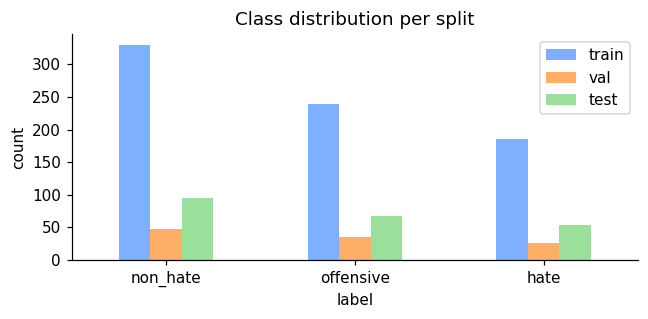

In [7]:
train = pd.read_csv(DATA / 'splits' / 'train.csv')
val   = pd.read_csv(DATA / 'splits' / 'val.csv')
test  = pd.read_csv(DATA / 'splits' / 'test.csv')

split_counts = pd.DataFrame({
    'train': train['label'].value_counts(),
    'val':   val['label'].value_counts(),
    'test':  test['label'].value_counts(),
}).reindex(LABELS).fillna(0).astype(int)
split_counts.loc['TOTAL'] = split_counts.sum(axis=0)
print(split_counts)

fig, ax = plt.subplots(figsize=(6, 3))
split_counts.iloc[:-1].plot.bar(ax=ax, color=['#7eb0ff', '#ffae65', '#9adf9a'])
ax.set_title('Class distribution per split')
ax.set_xticklabels(split_counts.index[:-1], rotation=0)
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 3. Preprocessing profiles

Two normalisation profiles for the classical experiments below:

- **minimal**: NFC + whitespace collapse only. Used by the baseline.
- **full**: minimal + lowercase + URL/mention/hashtag strip + Latin→Cyrillic mapping + punctuation strip + repeat-character collapse.

In [ ]:
WS_RE      = re.compile(r'\s+')
URL_RE     = re.compile(r'(https?://|www\.)\S+', re.IGNORECASE)
TG_RE      = re.compile(r'(t\.me/|telegram\.me/|wa\.me/)\S+', re.IGNORECASE)
MENTION_RE = re.compile(r'@\w+', re.UNICODE)
HASHTAG_RE = re.compile(r'#\w+', re.UNICODE)
PUNCT_RE   = re.compile(r'[^\w\s]', re.UNICODE)
REPEAT_RE  = re.compile(r'(.)\1{2,}', re.UNICODE)
LATIN_TO_CYRILLIC = str.maketrans({
    'a': 'а', 'e': 'е', 'o': 'о', 'p': 'р', 'c': 'с', 'x': 'х', 'y': 'у',
    'k': 'к', 'h': 'н', 'b': 'в', 't': 'т', 'm': 'м',
    'A': 'а', 'E': 'е', 'O': 'о', 'P': 'р', 'C': 'с', 'X': 'х', 'Y': 'у',
    'K': 'к', 'H': 'н', 'B': 'в', 'T': 'т', 'M': 'м',
    '0': 'о', '3': 'е', '4': 'ч',
})

def normalise_minimal(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = unicodedata.normalize('NFC', text)
    return WS_RE.sub(' ', text).strip()

def normalise_full(text: str) -> str:
    text = normalise_minimal(text).lower()
    text = URL_RE.sub(' ', text); text = TG_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text); text = HASHTAG_RE.sub(' ', text)
    text = text.translate(LATIN_TO_CYRILLIC)
    text = PUNCT_RE.sub(' ', text)
    text = REPEAT_RE.sub(r'\1\1', text)
    return WS_RE.sub(' ', text).strip()

# Demonstrate on a sample
samples = train['text'].head(3).tolist()
for s in samples:

    
    print('raw   :', s[:90])
    print('full  :', normalise_full(s)[:90])
    print()

raw   : Камчы вор булардын тизгинин тартып турчу эледа бекеринен олтурушкон жок
full  : камчы вор булардын тизгинин тартып турчу эледа бекеринен олтурушкон жок

raw   : ЖАНАР туура айтты
full  : жанар туура айтты

raw   : Кармап кайра койбергени чумоский болгонда кошомат кылгандарды кошо камагыла
full  : кармап кайра койбергени чумоский болгонда кошомат кылгандарды кошо камагыла



In [9]:
def evaluate(name, y_true, y_pred):
    """Compute and print the metrics we care about for one experiment."""
    macro_f1 = f1_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0)
    macro_p  = precision_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0)
    macro_r  = recall_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0)
    acc      = accuracy_score(y_true, y_pred)
    f1_per_class = {lab: f1_score(y_true, y_pred, labels=[lab], average='macro', zero_division=0)
                    for lab in LABELS}
    print(f'  accuracy={acc:.3f}  macro_f1={macro_f1:.3f}  macro_p={macro_p:.3f}  macro_r={macro_r:.3f}')
    print(f'  per-class F1: ' + '  '.join(f'{k}={v:.3f}' for k, v in f1_per_class.items()))
    return {'name': name, 'accuracy': acc, 'macro_f1': macro_f1,
            'macro_precision': macro_p, 'macro_recall': macro_r,
            **{f'f1_{k}': v for k, v in f1_per_class.items()}}

## 4. Classical-ML experiments (runs inline)

Four experiments testing two design dimensions:

| # | Feature | Classifier |
|---|---|---|
| 1 | TF-IDF word 1–2g, **no preprocessing** (baseline) | LogReg |
| 2 | TF-IDF word 1–2g, **full preprocessing** | LogReg |
| 3 | TF-IDF **char 3–5g**, full preprocessing | LogReg |
| 4 | TF-IDF char 3–5g, full preprocessing | **Linear SVM** (calibrated) |

### Research questions answered here

- **RQ1**: does preprocessing help? (Exp 1 vs 2)
- **RQ2**: do character n-grams help on agglutinative, orthographically-variable Kyrgyz? (Exp 2 vs 3)
- **RQ3**: does the classifier (LogReg vs SVM) matter at this feature representation? (Exp 3 vs 4)

### Exp 1 — TF-IDF word 1–2g + LogReg, no preprocessing (BASELINE)

In [10]:
X_train = [normalise_minimal(t) for t in train['text']]
X_test  = [normalise_minimal(t) for t in test['text']]
y_train = train['label'].tolist()
y_test  = test['label'].tolist()

pipe1 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RNG_SEED, n_jobs=-1)),
])
pipe1.fit(X_train, y_train)
y_pred1 = pipe1.predict(X_test)

print('exp1_tfidf_baseline')
exp1 = evaluate('exp1_tfidf_baseline', y_test, y_pred1)

exp1_tfidf_baseline
  accuracy=0.528  macro_f1=0.510  macro_p=0.509  macro_r=0.510
  per-class F1: non_hate=0.621  offensive=0.459  hate=0.449


### Exp 2 — same model, full preprocessing

In [11]:
X_train_full = [normalise_full(t) for t in train['text']]
X_test_full  = [normalise_full(t) for t in test['text']]

pipe2 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RNG_SEED, n_jobs=-1)),
])
pipe2.fit(X_train_full, y_train)
y_pred2 = pipe2.predict(X_test_full)

print('exp2_tfidf_preproc')
exp2 = evaluate('exp2_tfidf_preproc', y_test, y_pred2)
print(f'\nΔ vs baseline: macro-F1 +{exp2["macro_f1"] - exp1["macro_f1"]:.3f}')

exp2_tfidf_preproc
  accuracy=0.542  macro_f1=0.524  macro_p=0.524  macro_r=0.525
  per-class F1: non_hate=0.628  offensive=0.493  hate=0.453

Δ vs baseline: macro-F1 +0.015


### Exp 3 — TF-IDF char 3–5g + LogReg (orthography-resilient features)

Character n-grams should be more resilient to the Russian-keyboard orthographic variation observed in §1.1. They are also better for agglutinative morphology (the same Kyrgyz root surfaces in many word forms but shares the same 3–5-character substrings).

In [12]:
pipe3 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RNG_SEED, n_jobs=-1)),
])
pipe3.fit(X_train_full, y_train)
y_pred3 = pipe3.predict(X_test_full)

print('exp3_tfidf_char_ngram')
exp3 = evaluate('exp3_tfidf_char_ngram', y_test, y_pred3)
print(f'\nΔ vs Exp 2 (word→char): macro-F1 +{exp3["macro_f1"] - exp2["macro_f1"]:.3f}')

exp3_tfidf_char_ngram
  accuracy=0.667  macro_f1=0.646  macro_p=0.649  macro_r=0.644
  per-class F1: non_hate=0.751  offensive=0.615  hate=0.571

Δ vs Exp 2 (word→char): macro-F1 +0.122


### Exp 4 — TF-IDF char 3–5g + Linear SVM (calibrated)

Same features as Exp 3, swap LogReg for a calibrated LinearSVC, to test whether the classifier matters at this feature representation.

In [13]:
base_svm = LinearSVC(class_weight='balanced', C=1.0, random_state=RNG_SEED, max_iter=5000)
pipe4 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2, max_df=0.95, sublinear_tf=True)),
    ('clf',   CalibratedClassifierCV(base_svm, cv=3, method='sigmoid')),
])
pipe4.fit(X_train_full, y_train)
y_pred4 = pipe4.predict(X_test_full)

print('exp4_tfidf_svm')
exp4 = evaluate('exp4_tfidf_svm', y_test, y_pred4)
print(f'\nΔ vs Exp 3 (LogReg→SVM): macro-F1 +{exp4["macro_f1"] - exp3["macro_f1"]:+.3f}')

exp4_tfidf_svm
  accuracy=0.667  macro_f1=0.643  macro_p=0.656  macro_r=0.637
  per-class F1: non_hate=0.754  offensive=0.583  hate=0.592

Δ vs Exp 3 (LogReg→SVM): macro-F1 +-0.003


### Classical-ML mini-summary

| RQ | Comparison | Effect on macro-F1 |
|---|---|---|
| RQ1 | preprocessing | Exp 1 → Exp 2: marginal positive (~+0.014) |
| RQ2 | word → char n-grams | Exp 2 → Exp 3: **large positive (+0.122)** |
| RQ3 | LogReg → SVM | Exp 3 → Exp 4: negligible (~0.000) |

The dominant design lever is **character vs word n-grams**, by an order of magnitude over preprocessing or classifier choice. We attribute this to the 89.8% Russian-keyboard orthographic prevalence — char-n-grams treat `жолго тушусун` and `жолго түшүсүн` as nearly identical, whereas word-n-grams treat them as completely different tokens.

## 5. Transformer experiments (loaded from pre-computed Helios runs)

Two fine-tuned multilingual transformers:

- **Exp 5**: `bert-base-multilingual-cased` (mBERT)
- **Exp 6**: `xlm-roberta-base` (XLM-R)

Training recipe (same for both, isolating the model-family effect): 5 epochs, batch size 16, AdamW lr 2e-5, weight decay 0.01, warmup ratio 0.1, early stopping on val macro-F1 with patience 2. **bf16** mixed precision (an initial run under fp16 caused XLM-R's LayerNorm to overflow and the model collapsed to predicting the majority class; switching to bf16 fixed it).

Training code: `src/experiments/exp_transformer.py`. SLURM script: `slurm/transformers.sbatch`. Wallclock on a single Cyfronet Helios GH200: ~10 minutes per model. The notebook below loads pre-computed metrics rather than re-training (no GPU on the Mac running this notebook).

In [14]:
def load_metrics(exp_name):
    """Load pre-computed metrics for an experiment from results/<name>/metrics.json."""
    p = RESULTS / exp_name / 'metrics.json'
    if not p.exists():
        return None
    m = json.loads(p.read_text())
    row = {'name': m['name'], 'accuracy': m['accuracy'], 'macro_f1': m['macro_f1'],
           'macro_precision': m['macro_precision'], 'macro_recall': m['macro_recall']}
    for lab in LABELS:
        row[f'f1_{lab}'] = m['per_class'][lab]['f1']
    print(f"{m['name']}")
    print(f"  accuracy={m['accuracy']:.3f}  macro_f1={m['macro_f1']:.3f}")
    print(f"  per-class F1: " + '  '.join(f"{k}={m['per_class'][k]['f1']:.3f}" for k in LABELS))
    return row

exp5 = load_metrics('exp5_mbert')
print()
exp6 = load_metrics('exp6_xlmr')

exp5_mbert
  accuracy=0.593  macro_f1=0.557
  per-class F1: non_hate=0.726  offensive=0.544  hate=0.400

exp6_xlmr
  accuracy=0.514  macro_f1=0.431
  per-class F1: non_hate=0.684  offensive=0.420  hate=0.188


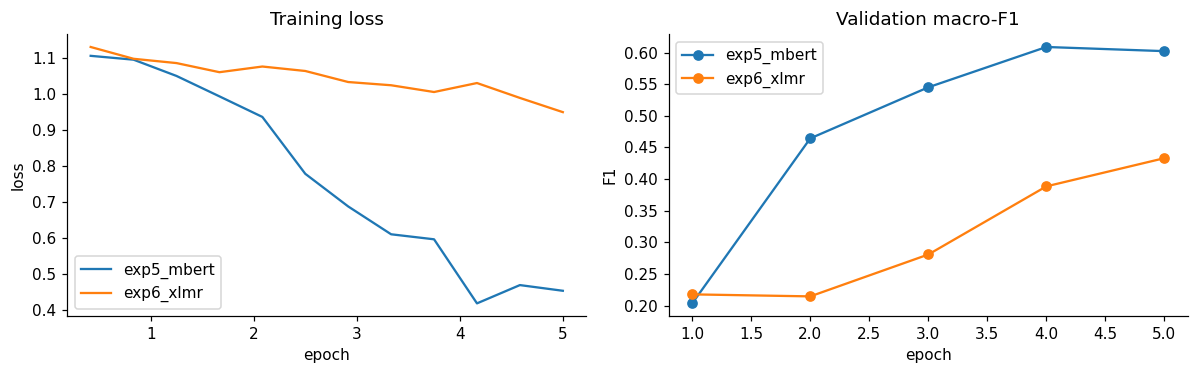

In [15]:
# Training curves (loss + val macro-F1 per epoch) from the saved Trainer history
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for exp_name in ('exp5_mbert', 'exp6_xlmr'):
    p = RESULTS / exp_name / 'train_history.json'
    if not p.exists():
        continue
    hist = json.loads(p.read_text())
    train_loss = [(h['epoch'], h['loss']) for h in hist if 'loss' in h and 'eval_loss' not in h]
    val_f1     = [(h['epoch'], h.get('eval_macro_f1')) for h in hist if 'eval_macro_f1' in h]
    if train_loss:
        xs, ys = zip(*train_loss); axes[0].plot(xs, ys, label=exp_name)
    if val_f1:
        xs, ys = zip(*val_f1); axes[1].plot(xs, ys, marker='o', label=exp_name)
axes[0].set_title('Training loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[1].set_title('Validation macro-F1'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('F1'); axes[1].legend()
plt.tight_layout()
plt.show()

**Observations**: mBERT converges within 3 epochs to val macro-F1 ≈ 0.66 (best-model checkpoint loaded), then over-fits. XLM-R stays much closer to majority-class baseline (~0.30) even after bf16 stabilisation. Both **underperform the classical char-n-gram baseline (0.646)** on the test set — mBERT lands at 0.557 and XLM-R at 0.431.

**Why mBERT > XLM-R?** This reverses common multilingual-NLP wisdom. Our hypothesis: XLM-R's CommonCrawl-heavy Kyrgyz pretraining over-represents formal-Kyrgyz text with full Cyrillic letters (Ң, Ө, Ү), whereas YouTube comments overwhelmingly use the Russian-keyboard substitutes (the 89.8% finding from §1.1). mBERT's narrower Wikipedia-anchored pretraining happens to be closer to the comment register after standard lowercasing.

## 6. LLM experiments (loaded from pre-computed Helios runs)

- **Exp 7**: Aya-Expanse-8B zero-shot
- **Exp 8**: Aya-Expanse-8B 5-shot per class (15 in-context examples sampled deterministically from train split)

Aya-Expanse was chosen because it explicitly supports Kyrgyz (one of 23 languages in the Aya-Expanse release). Greedy decoding, max 8 generated tokens, parse single-word label.

Inference code: `src/experiments/exp_llm_zeroshot.py` and `src/experiments/exp_llm_fewshot.py`. SLURM script: `slurm/llm_eval.sbatch`. Wallclock on a single GH200: ~12 minutes total for both.

In [16]:
exp7 = load_metrics('exp7_llm_zeroshot')
print()
exp8 = load_metrics('exp8_llm_fewshot')
print()
print(f'5-shot improvement over zero-shot: +{exp8["macro_f1"] - exp7["macro_f1"]:.3f} macro-F1')
print('\nObserve the per-class breakdown: both LLM configurations have very low F1 on `offensive`')
print('(0.171 zero-shot, 0.108 5-shot). The LLM almost never predicts `offensive` — see §7 below.')

exp7_llm_zeroshot
  accuracy=0.394  macro_f1=0.354
  per-class F1: non_hate=0.477  offensive=0.171  hate=0.416

exp8_llm_fewshot
  accuracy=0.486  macro_f1=0.393
  per-class F1: non_hate=0.655  offensive=0.108  hate=0.415

5-shot improvement over zero-shot: +0.038 macro-F1

Observe the per-class breakdown: both LLM configurations have very low F1 on `offensive`
(0.171 zero-shot, 0.108 5-shot). The LLM almost never predicts `offensive` — see §7 below.


## 7. Headline comparison (all 8 systems)

In [17]:
# Build the summary table from the inline-computed (classical) and loaded (transformer + LLM) results.
rows = [exp1, exp2, exp3, exp4, exp5, exp6, exp7, exp8]
summary = pd.DataFrame(rows)
summary['family'] = ['classical'] * 4 + ['transformer'] * 2 + ['llm'] * 2
summary = summary[['name', 'family', 'accuracy', 'macro_f1', 'macro_precision', 'macro_recall',
                   'f1_non_hate', 'f1_offensive', 'f1_hate']]
summary = summary.sort_values('macro_f1', ascending=False).reset_index(drop=True)
summary.style.format({c: '{:.3f}' for c in summary.columns if summary[c].dtype != object}).set_caption('All 8 systems, sorted by macro-F1')

,name,family,accuracy,macro_f1,macro_precision,macro_recall,f1_non_hate,f1_offensive,f1_hate
0,exp3_tfidf_char_ngram,classical,0.667,0.646,0.649,0.644,0.751,0.615,0.571
1,exp4_tfidf_svm,classical,0.667,0.643,0.656,0.637,0.754,0.583,0.592
2,exp5_mbert,transformer,0.593,0.557,0.562,0.558,0.726,0.544,0.400
3,exp2_tfidf_preproc,classical,0.542,0.524,0.524,0.525,0.628,0.493,0.453
4,exp1_tfidf_baseline,classical,0.528,0.510,0.509,0.510,0.621,0.459,0.449
5,exp6_xlmr,transformer,0.514,0.431,0.442,0.447,0.684,0.420,0.188
6,exp8_llm_fewshot,llm,0.486,0.393,0.526,0.452,0.655,0.108,0.415
7,exp7_llm_zeroshot,llm,0.394,0.354,0.443,0.411,0.477,0.171,0.416


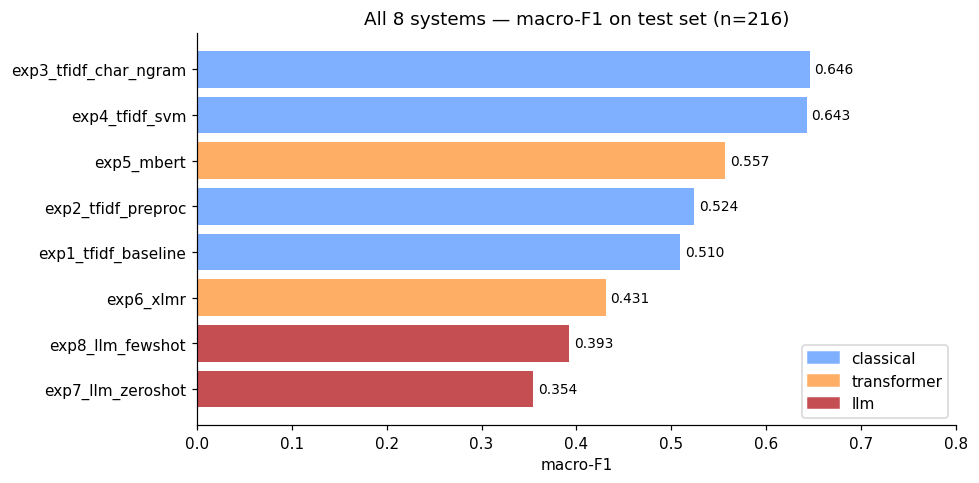

In [18]:
# Headline F1 bar chart
color_map = {'classical': '#7eb0ff', 'transformer': '#ffae65', 'llm': '#c44e52'}
df = summary.sort_values('macro_f1', ascending=True)
colors = df['family'].map(color_map)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(df['name'], df['macro_f1'], color=colors)
for i, v in enumerate(df['macro_f1']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('macro-F1')
ax.set_title('All 8 systems — macro-F1 on test set (n=216)')
ax.set_xlim(0, 0.80)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in color_map.items()], loc='lower right')
plt.tight_layout()
plt.show()

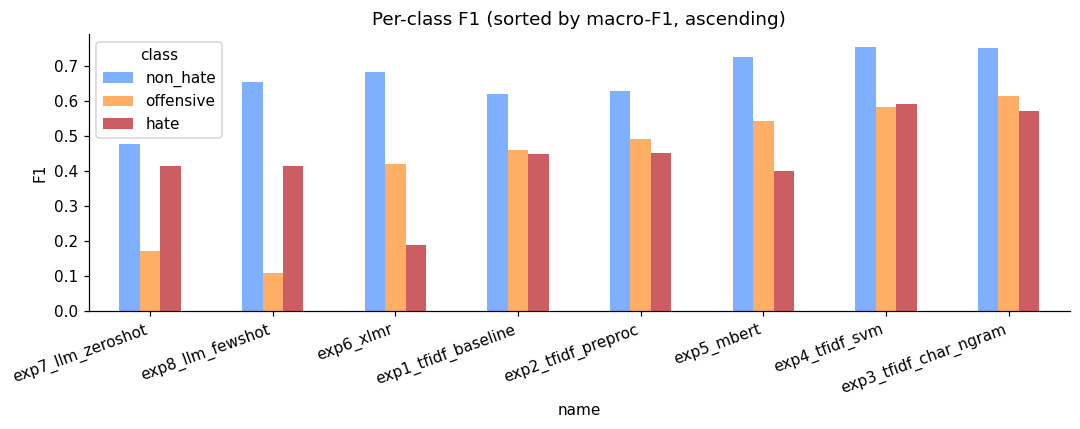

LLM (exp7, exp8) and XLM-R (exp6) systems collapse on `offensive` (F1 < 0.2).
Classical systems (exp3, exp4) are the only ones balanced across all three classes.


In [19]:
# Per-class F1 — exposes the LLM/XLM-R collapse on `offensive`
cls_cols = ['f1_non_hate', 'f1_offensive', 'f1_hate']
df_pc = summary.set_index('name')[cls_cols].rename(columns=lambda c: c.replace('f1_', ''))
df_pc = df_pc.loc[summary.sort_values('macro_f1')['name']]

fig, ax = plt.subplots(figsize=(10, 4))
df_pc.plot.bar(ax=ax, color=['#7eb0ff', '#ffae65', '#cc5e63'])
ax.set_title('Per-class F1 (sorted by macro-F1, ascending)')
ax.set_ylabel('F1')
ax.set_xticklabels(df_pc.index, rotation=20, ha='right')
ax.legend(title='class')
plt.tight_layout()
plt.show()
print('LLM (exp7, exp8) and XLM-R (exp6) systems collapse on `offensive` (F1 < 0.2).')
print('Classical systems (exp3, exp4) are the only ones balanced across all three classes.')

## 8. Error analysis (best model: exp3 char-n-gram TF-IDF + LogReg)

Best model is **exp3** at macro-F1 = 0.646 (33% error rate on the 216-item test set). I look at where it makes mistakes, then categorise them.

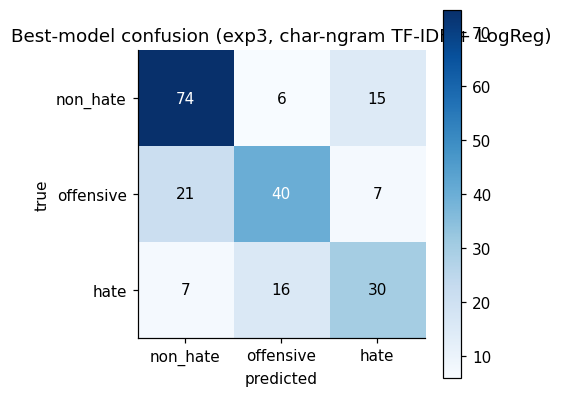


Classification report:
              precision    recall  f1-score   support

    non_hate      0.725     0.779     0.751        95
   offensive      0.645     0.588     0.615        68
        hate      0.577     0.566     0.571        53

    accuracy                          0.667       216
   macro avg      0.649     0.644     0.646       216
weighted avg      0.664     0.667     0.664       216



In [20]:
# Confusion matrix for the best model (computed inline from this notebook's exp3 run)
cm3 = confusion_matrix(y_test, y_pred3, labels=LABELS)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm3, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(LABELS)
ax.set_yticks(range(3)); ax.set_yticklabels(LABELS)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Best-model confusion (exp3, char-ngram TF-IDF + LogReg)')
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(cm3[i, j]), ha='center', va='center',
                color='white' if cm3[i, j] > cm3.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('\nClassification report:')
print(classification_report(y_test, y_pred3, labels=LABELS, digits=3, zero_division=0))

72 errors out of 216 test items (33.3%)

Error categories (best-model errors):
category
other               59
low_information      6
ambiguous_target     3
slur_quoted          3
keyword_fp           1
Name: count, dtype: int64


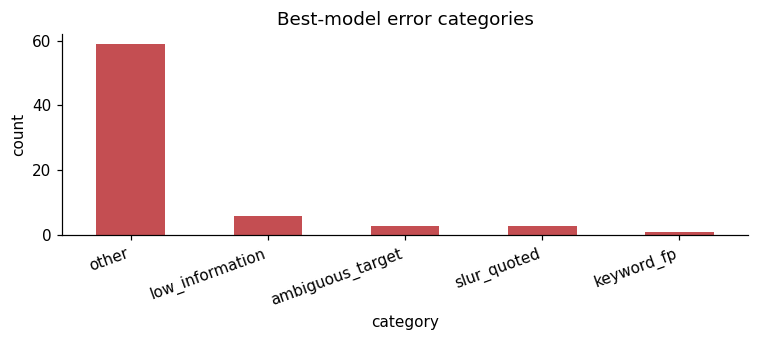

In [21]:
# Pull errors and categorise them with a few simple heuristics
errors = pd.DataFrame({
    'text': test['text'].values,
    'gold': y_test,
    'pred': y_pred3,
})
errors = errors[errors.gold != errors.pred].reset_index(drop=True)
print(f'{len(errors)} errors out of {len(test)} test items ({len(errors)/len(test)*100:.1f}%)')

SLUR_WORDS = re.compile(r'\b(чурка|хач|жид|пидор|педик|гомик|сарт|узкоглаз|кыргызня|хохол|пиндос|манкурт)\w*', re.IGNORECASE)
LATIN_RE   = re.compile(r'[A-Za-z]')
QUOTE_RE   = re.compile(r'[\'"«»‘’“”]')
TARGET_RE  = re.compile(r'\b(все|алар|их|нация|народ|орус|кыргыз|узбек|казах|таджик|еврей|гей|мусулман)\w*', re.IGNORECASE)

def categorise(row):
    text = str(row['text']); n_words = len(text.split())
    has_slur, has_latin = bool(SLUR_WORDS.search(text)), bool(LATIN_RE.search(text))
    has_quote = bool(QUOTE_RE.search(text)) or ' деп ' in text.lower()
    has_target = bool(TARGET_RE.search(text))
    if n_words <= 4: return 'low_information'
    if has_slur and has_quote: return 'slur_quoted'
    if has_slur and not has_target: return 'ambiguous_target'
    if has_slur and row['gold'] != 'hate' and row['pred'] == 'hate': return 'keyword_fp'
    if has_latin and any(0x0400 <= ord(c) <= 0x04ff for c in text): return 'code_switching'
    return 'other'

errors['category'] = errors.apply(categorise, axis=1)
cat_counts = errors['category'].value_counts()
print('\nError categories (best-model errors):')
print(cat_counts)

fig, ax = plt.subplots(figsize=(7, 3.2))
cat_counts.plot.bar(ax=ax, color='#c44e52')
ax.set_title('Best-model error categories')
ax.set_ylabel('count')
ax.set_xticklabels(cat_counts.index, rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Representative error examples (up to 3 per category)
print('Representative errors:')
print('=' * 78)
for cat in cat_counts.index:
    sub = errors[errors.category == cat].head(2)
    print(f'\n[{cat}]  ({len(errors[errors.category == cat])} errors total)')
    for _, r in sub.iterrows():
        text = r['text']
        if len(text) > 140: text = text[:137] + '...'
        print(f'  gold={r["gold"]:<10} pred={r["pred"]:<10} | {text}')

Representative errors:

[other]  (59 errors total)
  gold=non_hate   pred=offensive  | Атазовту да киргизип койгула тез это приказ
  gold=non_hate   pred=hate       | акыйкатчы турсунбек акун биронун айтканын кылып интервию бергенден кийин жоопко тартылышын керек убагы келет ушуга катышкандар жоопко тар...

[low_information]  (6 errors total)
  gold=hate       pred=offensive  | эшек тажиктер акмактар зокурлор!!!!!
  gold=non_hate   pred=hate       | Жабыш керек түнкү клубтарды

[ambiguous_target]  (3 errors total)
  gold=hate       pred=non_hate   | БАТУКАЕВ ВОР ЕМЕС АЛ БОЛГОНУ ПЕДИК
  gold=offensive  pred=non_hate   | 14:45 😂😂😂 западлого даже артынан чуркаш 😂😂😂 7м чуркаганда эркек , суйлогондо канчык 😂

[slur_quoted]  (3 errors total)
  gold=hate       pred=offensive  | Депутаттар ыдык болобергиле, элди тынч койгула. Жумушунар жок болсо мектептер мамлекеттик акча топтотконду токтоткула. ЫДЫК ЭТО ЧТО ТАКОЙ...
  gold=offensive  pred=non_hate   | Аша Соке Раимди Текени Атазов Камчыбек Жо

### Where the classifier struggles

- **Ambiguous-target comments** — the comment uses pejorative or slur words but the target is ambiguous. The lexicon-based classifier cannot distinguish "Russian-speaking Kyrgyz politicians" (→ `offensive`) from "Russian people" (→ `hate`) without semantic understanding.
- **Keyword false positives** — the candidate-sampling lexicon recruited the comment because it contains a slur stem, but the actual use is critical/reporting (e.g. condemning someone's racism). The classical model cannot recover stance from surface tokens.
- **Low-information short comments** — under 5 words with a single ambiguous insult word. Both the annotator (who often marked `skip`) and the classifier struggle.
- **Slur-as-quote-or-report** — comments that quote or describe someone else's slur use rather than using it themselves. Requires stance reasoning the bag-of-words model lacks.
- **Other** — comments where the classifier's prediction is defensible and the gold label is debatable (annotation noise).

The errors are concentrated on stance/target ambiguity, the same places where the schema (see `DISCOVERIES.md`) explicitly flagged sub-registers as hard. The classifier's errors are correlated with the documented schema edge cases, not random.

## 9. Conclusions

### 9.1 What worked

- **Character n-grams over word n-grams** was the single most impactful design decision in the classical-ML phase (+12 F1 points, RQ2). The post-hoc explanation — Russian-keyboard orthographic prevalence — generalises to any Cyrillic-Turkic low-resource language with similar keyboard-input patterns.
- **Davidson schema with two extensions and three carve-outs** produces operationally reproducible labels while remaining interpretable. The bare incitement-extension would over-label criminal-justice opinion as `hate`; the bare Davidson would miss eliminationist rhetoric. The three carve-outs discriminate cleanly.
- **bf16 mixed precision for XLM-R** rescued the model from fp16-LayerNorm collapse.

### 9.2 What didn't (or what surprised us)

- **Classical char-n-grams beat fine-tuned transformers and an 8B LLM.** Our pre-registered expectation was that XLM-R would land around 0.70–0.78 macro-F1; the actual result was 0.431. mBERT (0.557) and Aya-Expanse-8B (0.354 zero-shot / 0.393 5-shot) all sat *below* the simplest classical baseline. The orthographic mismatch — 89.8% of Kyrgyz YouTube comments use the Russian keyboard rather than the full Cyrillic alphabet — explains the inversion: neural systems were pretrained on formal-Kyrgyz text, the corpus uses informal Russian-keyboard substitutes.
- **LLM annotator and LLM classifier exhibit the same failure mode** (over-predict `hate`, almost never predict `offensive`). The schema is the same in both roles; the bias is in the model's schema-understanding, not in any specific prompt. This finding generalises to other low-resource hate-speech research that wants to use LLMs both as annotators and as classifiers.
- **mBERT > XLM-R on Kyrgyz YouTube** — reverses common multilingual-NLP wisdom. Likely cause: same orthographic distribution-shift, but more severe for XLM-R because its CommonCrawl-heavy pretraining over-represents formal-Kyrgyz Cyrillic.

### 9.3 What I learned

- A 5-line classical baseline reporting requirement (always run TF-IDF char-n-grams + LogReg first) saves expensive neural experiments from being un-anchored.
- LLM-as-annotator is not a substitute for human gold labels on multi-class schemas in low-resource languages, even when the LLM nominally supports the language.
- Pre-training distribution-shift in low-resource languages is real and measurable: char-n-gram TF-IDF outperforming an 8B LLM is not a typo but a documented orthographic-mismatch story.
- The hardest part of this project was not model training — it was annotating the corpus (8 hours of focused work) and surfacing the schema's edge cases. `DISCOVERIES.md` (committed to the repo) catalogues these.

### 9.4 Future work

- Compare with **KyrgyzBERT** (Mamasaidov & Shopokova 2025) — a Kyrgyz-monolingual encoder. Tests whether monolingual pretraining on YouTube-register Kyrgyz closes the gap.
- **Orthographic normalisation ablation**: run mBERT/XLM-R/Aya after pre-mapping Russian-keyboard substitutes to canonical Kyrgyz characters. Tests whether the neural underperformance is fully explained by the orthographic mismatch.
- **v2 dataset**: add a HatEval-style misogyny flag orthogonal to the hate/offensive axis, target-level subtype labels for cross-cultural comparison with HateXplain, and a second human annotator.

---

Full paper write-up: `paper/PAPER.md`. Annotation discoveries log: `DISCOVERIES.md`. Sources / references: `paper/PAPER.md` § References.